# PFA ALSA — Prevision de la demande voyageurs
Pipeline complet : chargement, EDA, feature engineering, LSTM, comparaison de modeles, interpretation.

**A faire avant de lancer** : uploader `BD_EXPLOITATION_clean.csv` dans votre Drive et adapter `DATA_PATH`.

In [1]:
# Installation des librairies
!pip install -q statsmodels xgboost

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MODELS_DIR = '/content/drive/MyDrive/alsa_pfa_corrige/models'

## 1. Chargement et nettoyage des donnees brutes
On part directement du fichier Excel original (`BD_EXPLOITATION.xlsx`, onglet `BD`) pour que le nettoyage soit trace et reproductible dans le rapport.

In [6]:
RAW_PATH = '/content/drive/MyDrive/alsa_pfa_corrige/data/raw/BD EXPLOITATION(ESSAI).xlsx'
CLEAN_PATH = '/content/drive/MyDrive/alsa_pfa_corrige/data/processed/BD_EXPLOITATION_clean.csv'

cols = ['date','ligne','passagers','billets','ikhlas','transfert','ikhlas_transfert',
        'etudiants','recette','bus','km','type_jour','type_ligne','horas']

raw = pd.read_excel(RAW_PATH, sheet_name='BD', usecols=range(len(cols)), header=0, names=cols)
raw['date'] = pd.to_datetime(raw['date'])
raw['ligne'] = raw['ligne'].astype(str)

print('Shape brute :', raw.shape)

Shape brute : (49136, 14)


In [7]:
# --- Etapes de nettoyage ---

# 1) lignes sans identifiant de ligne (valeur manquante)
df = raw.dropna(subset=['ligne']).copy()

# 2) doublons date+ligne (on garde la premiere occurrence)
nb_doublons = df.duplicated(subset=['date','ligne']).sum()
df = df.drop_duplicates(subset=['date','ligne'], keep='first')
print(f'Doublons date+ligne supprimes : {nb_doublons}')

# 3) lignes jamais frequentees (0 passager sur toute la periode) -> inactives, on les exclut
totaux = df.groupby('ligne')['passagers'].sum()
lignes_inactives = totaux[totaux == 0].index.tolist()
print('Lignes inactives exclues :', lignes_inactives)

# 4) lignes a exclure manuellement :
#    22 (remplacee par le BHNS), 28, TVM, navette speciale, transport personnel,
#    ligne evenementielle Timitar, et le BHNS lui-meme (donnees encore trop recentes/instables)
lignes_exclusion_manuelle = ['22', '28', '352', 'TVM', '357- NAVETTE SPECIALE',
                             'TRANSPORT PERSONNEL 362', 'SP- TIMITAR -355', 'BHNS']
lignes_a_exclure = list(set(lignes_inactives + lignes_exclusion_manuelle))
df = df[~df['ligne'].isin(lignes_a_exclure)]

# 5) on coupe le dataset a la derniere date ou on a reellement des donnees
#    (au-dela, ce sont des lignes calendaires vides deja preformatees dans le fichier)
somme_par_jour = df.groupby('date')['passagers'].sum()
derniere_date_reelle = somme_par_jour[somme_par_jour > 0].index.max()
df = df[df['date'] <= derniere_date_reelle]

df = df.sort_values(['ligne','date']).reset_index(drop=True)

print('Shape apres nettoyage :', df.shape)
print('Nb lignes actives conservees :', df['ligne'].nunique())
print('Periode :', df['date'].min(), '->', df['date'].max())

Doublons date+ligne supprimes : 2
Lignes inactives exclues : ['07-72', '18', '19', '25', '34', '352', '4', '81', 'TVM', 'nan']
Shape apres nettoyage : (35148, 14)
Nb lignes actives conservees : 38
Periode : 2024-01-01 00:00:00 -> 2026-07-14 00:00:00


In [8]:
# Sauvegarde du CSV nettoye, reutilisable directement (evite de refaire le nettoyage a chaque fois)
import os
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)
df.to_csv(CLEAN_PATH, index=False)
df.head()

,date,ligne,passagers,billets,ikhlas,transfert,ikhlas_transfert,etudiants,recette,bus,km,type_jour,type_ligne,horas
0,2024-01-01,1,0,0,0,0,0,0,0.0,0.0,0.000,LV,URB,0.000000
1,2024-01-02,1,700,255,126,48,174,267,1255.0,1.0,132.904,LV,URB,10.516667
2,2024-01-03,1,655,189,115,45,160,303,1087.0,1.0,132.904,LV,URB,10.516667
3,2024-01-04,1,731,167,123,44,167,387,916.0,1.0,132.904,LV,URB,10.516667
4,2024-01-05,1,604,126,99,55,154,318,778.0,1.0,132.904,LV,URB,10.516667


**Choix de la ligne de reference** : la ligne 12 (grande ligne urbaine, bien fournie en donnees). Elle sert a illustrer l'EDA, a caler les hyperparametres (Optuna) et a comparer les modeles (section 6) ; le LSTM final (section 8) est ensuite applique a TOUTES les lignes, pas seulement celle-ci.

In [9]:
LIGNE_REFERENCE = '12'   # a changer pour tester une autre ligne (grande, moyenne, reguliere...)

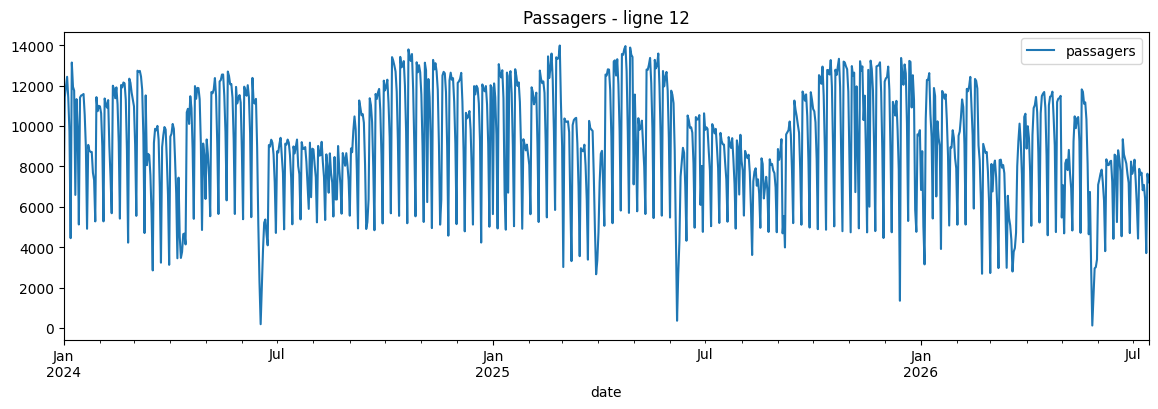

In [10]:
def preparer_serie(df, ligne):
    """Isole une ligne, la met en frequence journaliere continue, interpole les trous,
    et applique la regle metier de la ligne 73 (a l'arret en juillet-aout)."""
    colonnes_utiles = ['passagers', 'type_jour', 'type_ligne', 'bus', 'horas']
    s = df[df['ligne'] == ligne].sort_values('date').set_index('date')[colonnes_utiles]
    s = s.asfreq('D')
    s['passagers'] = s['passagers'].interpolate(method='time')
    s['type_ligne'] = s['type_ligne'].ffill().bfill()
    s['type_jour'] = s['type_jour'].fillna('LV')
    s['bus'] = s['bus'].interpolate(method='time')
    s['horas'] = s['horas'].interpolate(method='time')
    if str(ligne) == '73':
        s = s[~s.index.month.isin([7, 8])]
    return s

# Selection de la ligne de reference et mise en serie temporelle continue (un point par jour)
serie = preparer_serie(df, LIGNE_REFERENCE)
serie[['passagers']].plot(figsize=(14,4), title=f'Passagers - ligne {LIGNE_REFERENCE}')
plt.show()

## 2. EDA rapide

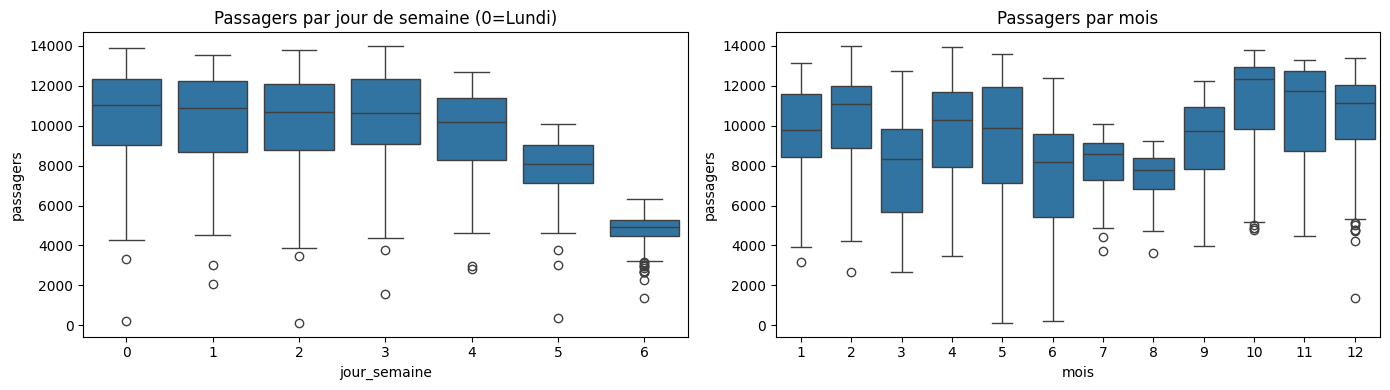

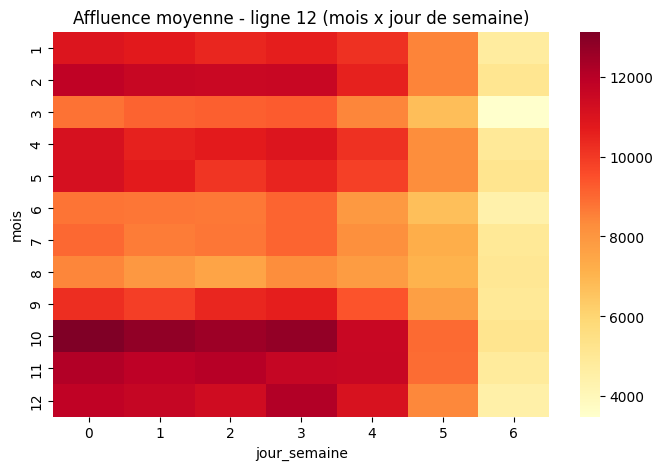

In [11]:
# Distribution par jour de semaine et par mois
tmp = serie.copy()
tmp['jour_semaine'] = tmp.index.dayofweek   # 0=lundi ... 6=dimanche
tmp['mois'] = tmp.index.month

fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.boxplot(x='jour_semaine', y='passagers', data=tmp, ax=axes[0])
axes[0].set_title('Passagers par jour de semaine (0=Lundi)')
sns.boxplot(x='mois', y='passagers', data=tmp, ax=axes[1])
axes[1].set_title('Passagers par mois')
plt.tight_layout(); plt.show()

# Heatmap mois x jour de semaine (utile pour identifier les periodes de forte/faible affluence)
pivot = tmp.pivot_table(index='mois', columns='jour_semaine', values='passagers', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title(f'Affluence moyenne - ligne {LIGNE_REFERENCE} (mois x jour de semaine)')
plt.show()

## 3. Feature engineering

### 3.1 Calendrier des jours feries marocains
En plus de `is_vacances` (deduite de `type_jour == 'OTROS'`), on ajoute le calendrier officiel des jours feries marocains. On separe :
- `is_aid` : specifiquement l'Aid al-Fitr et l'Aid al-Adha (2 jours chacun), qui provoquent historiquement la plus forte baisse d'affluence (deplacements familiaux, exode des villes) ;
- `is_ferie` : les autres jours feries (fetes civiles + Aid Al Mawlid + 1er Moharram).

**A mettre a jour chaque annee** : les fetes religieuses suivent le calendrier lunaire et sont annoncees par le ministere des Habous seulement quelques jours a l'avance ; les dates ci-dessous sont deja connues/confirmees pour 2024-2026, il faudra ajouter 2027 le moment venu.

In [12]:
# Fetes religieuses a dates variables (calendrier lunaire), confirmees par le ministere des Habous
DATES_AID = [
    # Aid al-Fitr (fin du Ramadan)
    '2024-04-10', '2024-04-11',
    '2025-03-31', '2025-04-01',
    '2026-03-20', '2026-03-21',
    # Aid al-Adha (fete du sacrifice)
    '2024-06-17', '2024-06-18',
    '2025-06-06', '2025-06-07',
    '2026-05-27', '2026-05-28',
]

DATES_AUTRES_FERIES_RELIGIEUX = [
    '2024-07-07',   # 1er Moharram 1446
    '2024-09-16',   # Aid Al Mawlid 1446
    '2025-06-27',   # 1er Moharram 1447
    '2025-09-05',   # Aid Al Mawlid 1447
    '2026-06-17',   # 1er Moharram 1448
    '2026-08-26',   # Aid Al Mawlid 1448
]

# Fetes civiles a dates fixes (memes jours chaque annee)
JOURS_FERIES_FIXES = [(1,1), (1,11), (1,14), (5,1), (7,30), (8,14), (8,20), (8,21), (11,6), (11,18)]

ANNEES_COUVERTES = [2024, 2025, 2026]
dates_feries_fixes = [pd.Timestamp(annee, mois, jour)
                      for annee in ANNEES_COUVERTES for (mois, jour) in JOURS_FERIES_FIXES]

SET_DATES_AID = set(pd.to_datetime(DATES_AID))
SET_DATES_FERIES = set(pd.to_datetime(DATES_AUTRES_FERIES_RELIGIEUX)) | set(dates_feries_fixes)

print(f'{len(SET_DATES_AID)} jours d ete/Aid, {len(SET_DATES_FERIES)} autres jours feries repertories.')

12 jours d ete/Aid, 36 autres jours feries repertories.


### Calendrier des jours feries marocains
Jours feries civils (dates fixes chaque annee) + fetes religieuses mobiles (dates confirmees par le ministere des Habous, calendrier lunaire donc differentes chaque annee). L'Aid El Fitr et l'Aid El Adha sont historiquement des jours de tres faible frequentation (commerces/administrations fermes, deplacements familiaux) : on les isole avec `is_eid` en plus du `is_ferie` general.

In [13]:
# Jours feries civils : memes dates chaque annee
JOURS_FERIES_FIXES = [
    (1, 1),   # Nouvel An
    (1, 11),  # Manifeste de l'Independance
    (5, 1),   # Fete du Travail
    (7, 30),  # Fete du Trone
    (8, 14),  # Anniversaire recuperation Oued Ed-Dahab
    (8, 20),  # Revolution du Roi et du Peuple
    (8, 21),  # Fete de la Jeunesse
    (11, 6),  # Marche Verte
    (11, 18), # Fete de l'Independance
]

# Aid El Fitr / Aid El Adha : dates confirmees (calendrier lunaire, verifiees par annee)
# A mettre a jour chaque annee (ministere des Habous et des Affaires islamiques)
DATES_AID_FITR = ['2024-04-10', '2025-03-31', '2026-03-20']
DATES_AID_ADHA = ['2024-06-17', '2025-06-07', '2025-06-09', '2026-05-27', '2026-05-28']

dates_aid_fitr = pd.to_datetime(DATES_AID_FITR)
dates_aid_adha = pd.to_datetime(DATES_AID_ADHA)
dates_aid = dates_aid_fitr.union(dates_aid_adha)

def est_jour_ferie(date):
    if (date.month, date.day) in JOURS_FERIES_FIXES:
        return True
    return date.normalize() in dates_aid

def est_jour_aid(date):
    return date.normalize() in dates_aid

In [14]:
def add_features(s):
    d = s.copy()
    d['jour_semaine'] = d.index.dayofweek   # 0=lundi ... 6=dimanche
    d['mois'] = d.index.month

    # jours feries (civils + Aid El Fitr/Aid El Adha) : forte baisse d'activite attendue
    d['is_ferie'] = [int(est_jour_ferie(dt)) for dt in d.index]
    d['is_eid'] = [int(est_jour_aid(dt)) for dt in d.index]

    # OTROS = vacances scolaires : comportement different meme un jour de semaine normal
    d['is_vacances'] = (d['type_jour'] == 'OTROS').astype(int)

    # Un jour ferie (JF fixe ou Aid) se comporte comme un dimanche, quel que soit le vrai jour
    # de la semaine ce jour-la (ex. un jeudi ferie se vide comme un dimanche, pas comme un jeudi).
    # On force donc l'encodage du jour de la semaine sur 'dimanche' (6) pour ces dates, et on
    # aligne is_weekend en consequence. is_ferie/is_eid restent en plus, pour que le modele
    # puisse apprendre une baisse encore plus marquee que celle d'un dimanche ordinaire
    # (frequent pour l'Aid, ou l'activite peut etre plus faible qu'un dimanche normal).
    jour_semaine_ajuste = d['jour_semaine'].where(d['is_ferie'] == 0, 6)
    d['is_weekend'] = np.where(d['is_ferie'] == 1, 1, (d['jour_semaine'] >= 5).astype(int))

    # comportement propre a chaque jour (lundi different de mardi, different du weekend...)
    # -> one-hot explicite plutot qu'un simple sin/cos, qui suppose une transition lisse entre jours
    dummies_jour = pd.get_dummies(jour_semaine_ajuste, prefix='jour').astype(int)
    for i in range(7):
        col = f'jour_{i}'
        if col not in dummies_jour:
            dummies_jour[col] = 0
    d = pd.concat([d, dummies_jour], axis=1)

    # saisonnalite mensuelle : encodage cyclique (le mois, lui, varie de facon lisse/continue)
    d['sin_mois'] = np.sin(2*np.pi*d['mois']/12)
    d['cos_mois'] = np.cos(2*np.pi*d['mois']/12)

    # lags courts
    d['lag_1'] = d['passagers'].shift(1)
    d['lag_7'] = d['passagers'].shift(7)
    d['rolling_mean_7'] = d['passagers'].shift(1).rolling(7).mean()
    d['rolling_mean_30'] = d['passagers'].shift(1).rolling(30).mean()

    # comportement du meme jour les annees precedentes (meme jour l'an dernier / il y a 2 ans)
    # NB: avec ~2.5 ans d'historique, le lag a 2 ans n'existe que sur les derniers mois
    # -> on utilise le lag a 1 an comme valeur de repli pour ne pas perdre trop de lignes
    d['lag_365'] = d['passagers'].shift(365)
    d['lag_730'] = d['passagers'].shift(730)
    # si une ligne n'a pas encore 1 an d'historique (ex. BHNS, ligne recente), on utilise
    # la moyenne glissante comme valeur de repli plutot que de perdre toute la ligne au dropna
    d['lag_365'] = d['lag_365'].fillna(d['rolling_mean_30'])
    d['lag_730'] = d['lag_730'].fillna(d['lag_365'])

    # IMPORTANT : on exclut 'bus' du dropna. Lors d'une prevision recursive (voir sections 7.2
    # et l'API), les jours futurs qu'on ajoute a l'historique n'ont pas de 'bus' connu (NaN).
    # Un dropna() global effacerait alors CHAQUE jour predit avant qu'il ne serve a construire
    # la fenetre suivante -> le modele recevrait toujours la meme fenetre (les derniers vrais
    # jours) et produirait une prediction constante, jour apres jour. D'ou ce dropna cible.
    colonnes_essentielles = [c for c in d.columns if c not in ('bus', 'horas')]
    return d.dropna(subset=colonnes_essentielles)

data_feat = add_features(serie)
data_feat.head()

,passagers,type_jour,type_ligne,bus,horas,jour_semaine,mois,is_ferie,is_eid,is_vacances,...,jour_5,jour_6,sin_mois,cos_mois,lag_1,lag_7,rolling_mean_7,rolling_mean_30,lag_365,lag_730
date,,,,,,,,,,,,,,,,,,,,,
2024-01-31,11003.0,LV,URB,12.5,185.883333,2,1,0,0,0,...,0,0,0.500000,0.866025,10739.0,8729.0,8559.000000,9524.866667,9524.866667,9524.866667
2024-02-01,10974.0,LV,URB,12.5,169.850000,3,2,0,0,0,...,0,0,0.866025,0.500000,11003.0,8717.0,8883.857143,9683.133333,9683.133333,9683.133333
2024-02-02,10633.0,LV,URB,12.5,170.750000,4,2,0,0,0,...,0,0,0.866025,0.500000,10974.0,7688.0,9206.285714,9667.533333,9667.533333,9667.533333
2024-02-03,9016.0,S,URB,10.0,146.666667,5,2,0,0,0,...,1,0,0.866025,0.500000,10633.0,7327.0,9627.000000,9623.266667,9623.266667,9623.266667
2024-02-04,5280.0,D,URB,6.0,94.866667,6,2,0,0,0,...,0,1,0.866025,0.500000,9016.0,5279.0,9868.285714,9509.066667,9509.066667,9509.066667


## 4. Pretraitement LSTM : normalisation et sequences

In [15]:
FEATURES = ['passagers','is_vacances','is_weekend','is_ferie','is_eid',
            'jour_0','jour_1','jour_2','jour_3','jour_4','jour_5','jour_6',
            'sin_mois','cos_mois',
            'lag_1','lag_7','lag_365','lag_730',
            'rolling_mean_7','rolling_mean_30']
WINDOW_SIZE = 30   # nb de jours d'historique utilises pour predire le jour suivant

n = len(data_feat)
train_end = int(n*0.80)
val_end   = int(n*0.90)

train_df = data_feat.iloc[:train_end]
val_df   = data_feat.iloc[train_end:val_end]
test_df  = data_feat.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])   # fit UNIQUEMENT sur le train : evite la fuite de donnees

train_scaled = scaler.transform(train_df[FEATURES])
val_scaled   = scaler.transform(val_df[FEATURES])
test_scaled  = scaler.transform(test_df[FEATURES])

def create_sequences(arr, window_size, target_col_idx=0):
    X, y = [], []
    for i in range(len(arr) - window_size):
        X.append(arr[i:i+window_size])
        y.append(arr[i+window_size, target_col_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled, WINDOW_SIZE)

print('Shapes :', X_train.shape, X_val.shape, X_test.shape)

Shapes : (686, 30, 20) (60, 30, 20) (60, 30, 20)


## 5. Optimisation des hyperparametres (Optuna) puis entrainement du LSTM
Plutot que de choisir a la main le nombre de neurones, le dropout, le learning rate et la taille de batch, on utilise **Optuna** : a chaque essai (`trial`), il propose une combinaison d'hyperparametres, entraine un modele court, regarde l'erreur de validation, et affine sa recherche vers les zones prometteuses (recherche bayesienne, plus efficace qu'une grille exhaustive). On fait cette recherche **une seule fois sur la ligne de reference** : les hyperparametres trouves sont ensuite reutilises pour toutes les lignes (section 8) et le modele global (section 9), plutot que de relancer Optuna 43 fois, ce qui serait beaucoup trop long.

In [16]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.4 MB/s eta 0:00:00


In [17]:
import optuna
from tensorflow.keras.optimizers import Adam

def construire_modele(n_features, window_size, hp):
    """Construit un LSTM empile a 2 couches, a partir d'un dict d'hyperparametres hp
    contenant : units1, units2, dropout, learning_rate."""
    m = Sequential([
        LSTM(hp['units1'], return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(hp['dropout']),
        LSTM(hp['units2']),
        Dropout(hp['dropout']),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer=Adam(learning_rate=hp['learning_rate']), loss='mse', metrics=['mae'])
    return m

def objectif_optuna(trial):
    hp = {
        'units1': trial.suggest_categorical('units1', [32, 64, 96, 128]),
        'units2': trial.suggest_categorical('units2', [16, 32, 64]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
    }
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])

    m = construire_modele(len(FEATURES), WINDOW_SIZE, hp)
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    hist = m.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=60, batch_size=batch_size, callbacks=[es], verbose=0)
    return min(hist.history['val_loss'])

study = optuna.create_study(direction='minimize')
study.optimize(objectif_optuna, n_trials=20, show_progress_bar=True)

print('Meilleurs hyperparametres trouves :', study.best_params)
print('Meilleure perte de validation :', study.best_value)

MEILLEURS_HP = {
    'units1': study.best_params['units1'],
    'units2': study.best_params['units2'],
    'dropout': study.best_params['dropout'],
    'learning_rate': study.best_params['learning_rate'],
}
MEILLEUR_BATCH_SIZE = study.best_params['batch_size']

[I 2026-08-04 10:34:02,569] A new study created in memory with name: no-name-d89399b1-d888-458a-835a-9183d470632e


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[I 2026-08-04 10:35:38,138] Trial 0 finished with value: 0.010577920824289322 and parameters: {'units1': 128, 'units2': 16, 'dropout': 0.369693981850198, 'learning_rate': 0.006016088000218544, 'batch_size': 32}. Best is trial 0 with value: 0.010577920824289322.
[I 2026-08-04 10:36:55,627] Trial 1 finished with value: 0.008323605172336102 and parameters: {'units1': 96, 'units2': 32, 'dropout': 0.23016532426302447, 'learning_rate': 0.0011612305821745877, 'batch_size': 8}. Best is trial 1 with value: 0.008323605172336102.
[I 2026-08-04 10:38:38,064] Trial 2 finished with value: 0.007800504099577665 and parameters: {'units1': 128, 'units2': 16, 'dropout': 0.11941656227105027, 'learning_rate': 0.00032778194195759073, 'batch_size': 16}. Best is trial 2 with value: 0.007800504099577665.
[I 2026-08-04 10:39:25,438] Trial 3 finished with value: 0.019626624882221222 and parameters: {'units1': 32, 'units2': 32, 'dropout': 0.22382929571882504, 'learning_rate': 0.000248331796336289, 'batch_size': 3

In [18]:
import os
os.makedirs(MODELS_DIR, exist_ok=True)

model = construire_modele(len(FEATURES), WINDOW_SIZE, MEILLEURS_HP)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint(f'{MODELS_DIR}/lstm_ligne{LIGNE_REFERENCE}.keras', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=MEILLEUR_BATCH_SIZE,
    callbacks=callbacks, verbose=1
)

joblib.dump(scaler, f'{MODELS_DIR}/scaler_ligne{LIGNE_REFERENCE}.pkl')

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 30, 96)         │        44,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 32)             │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,985 (242.13 KB)

 Trainable params: 61,985 (242.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - loss: 0.1123 - mae: 0.2609 - val_loss: 0.0383 - val_mae: 0.1609
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0527 - mae: 0.1846 - val_loss: 0.0417 - val_mae: 0.1658
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0509 - mae: 0.1820 - val_loss: 0.0397 - val_mae: 0.1615
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0450 - mae: 0.1725 - val_loss: 0.0382 - val_mae: 0.1581
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0443 - mae: 0.1703 - val_loss: 0.0368 - val_mae: 0.1536
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0443 - mae: 0.1694 - val_loss: 0.0345 - val_mae: 0.1481
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0455 - mae: 0.1737 - val_loss: 0.0352 - val_mae: 0.1497
Epoch 8/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0443 - mae: 0.1724 - val_loss: 0.0339 - val_mae: 0.1475
Epoch 9/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - l

['/content/drive/MyDrive/alsa_pfa_corrige/models/scaler_ligne12.pkl']

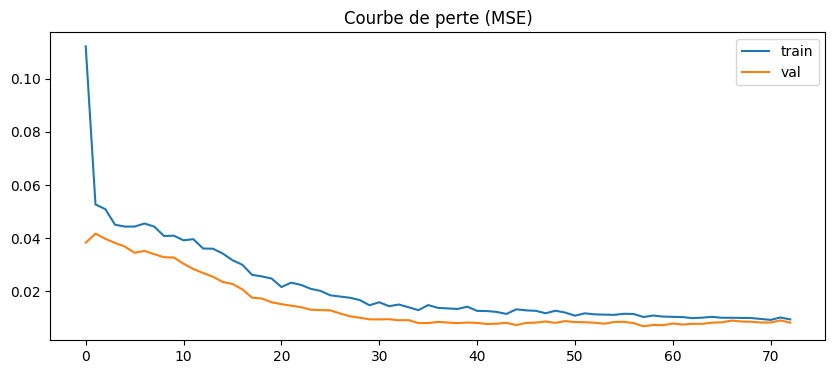

In [19]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Courbe de perte (MSE)'); plt.legend(); plt.show()

In [20]:
# Fonction pour re-transformer les predictions normalisees vers l'echelle reelle
def inverse_target(scaled_values, scaler, n_features, target_idx=0):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_pred_lstm_scaled = model.predict(X_test).flatten()
y_pred_lstm = inverse_target(y_pred_lstm_scaled, scaler, len(FEATURES))
y_test_real = inverse_target(y_test, scaler, len(FEATURES))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step


## 6. Comparaison avec d'autres modeles
Meme decoupage temporel, memes cibles reelles, pour une comparaison equitable.

In [21]:
# Baseline naive : prediction(t) = valeur reelle(t-1)
# on reconstruit sur les memes index que test_df pour rester coherent avec le decoupage
test_target_series = test_df['passagers'].iloc[WINDOW_SIZE:]
baseline_pred = test_df['passagers'].shift(1).iloc[WINDOW_SIZE:].values

# Random Forest sur les memes features tabulaires (pas de sequence, juste la ligne de features)
X_train_tab = train_df[FEATURES].iloc[:-1]
y_train_tab = train_df['passagers'].shift(-1).dropna()
X_train_tab = X_train_tab.iloc[:len(y_train_tab)]

X_test_tab = test_df[FEATURES].iloc[WINDOW_SIZE:]

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=SEED)
rf.fit(X_train_tab, y_train_tab)
y_pred_rf = rf.predict(X_test_tab)

### 6.1 Modele statistique classique : Holt-Winters
Ce modele est univarie (il ne regarde que la serie `passagers`, pas les features) et est entraine uniquement sur les donnees d'avant le test (train + val), puis projete sur le meme horizon que les autres modeles.

In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

historique_avant_test = pd.concat([train_df, val_df])['passagers']
horizon_test = len(test_target_series)

# Holt-Winters : lissage exponentiel avec tendance et saisonnalite hebdomadaire (m=7)
hw_model = ExponentialSmoothing(
    historique_avant_test, trend='add', seasonal='add', seasonal_periods=7
).fit()
y_pred_hw = hw_model.forecast(horizon_test).values

In [23]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Modele': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R2': r2}

results = pd.DataFrame([
    evaluate(test_target_series.values, baseline_pred, 'Naif (t-1)'),
    evaluate(test_target_series.values, y_pred_hw, 'Holt-Winters'),
    evaluate(y_test_real, y_pred_rf, 'Random Forest'),
    evaluate(y_test_real, y_pred_lstm, 'LSTM'),
])
results.sort_values('RMSE')

,Modele,MAE,RMSE,MAPE (%),R2
3,LSTM,1040.326659,1668.704709,122.833546,0.499311
0,Naif (t-1),1596.500000,2270.956781,66.658349,0.072687
2,Random Forest,1758.987479,2496.273707,77.981811,-0.120452
1,Holt-Winters,4138.258884,4833.549460,238.252061,-3.200888


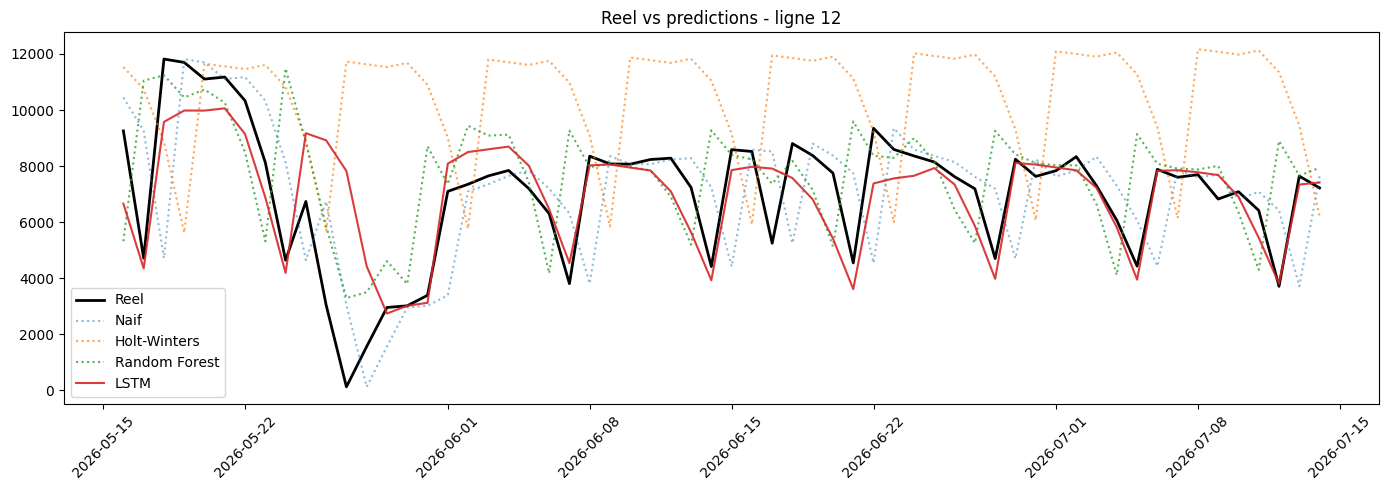

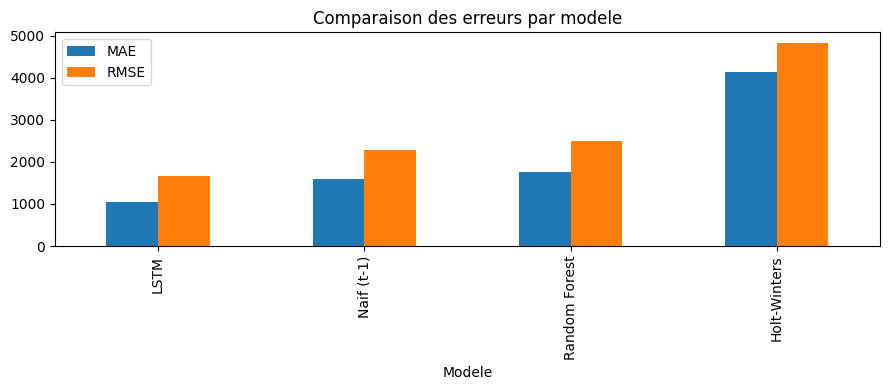

In [24]:
plt.figure(figsize=(14,5))
plt.plot(test_target_series.index, test_target_series.values, label='Reel', linewidth=2, color='black')
plt.plot(test_target_series.index, baseline_pred, label='Naif', alpha=0.5, linestyle=':')
plt.plot(test_target_series.index, y_pred_hw, label='Holt-Winters', alpha=0.7, linestyle=':')
plt.plot(test_target_series.index, y_pred_rf, label='Random Forest', alpha=0.8, linestyle=':')
plt.plot(test_target_series.index, y_pred_lstm, label='LSTM', alpha=0.9)
plt.title(f'Reel vs predictions - ligne {LIGNE_REFERENCE}')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

results.set_index('Modele')[['MAE','RMSE']].sort_values('RMSE').plot(
    kind='bar', figsize=(9,4), title='Comparaison des erreurs par modele')
plt.tight_layout(); plt.show()

## 7. Estimation du nombre de bus necessaires
Attention : `passagers` est un total JOURNALIER qui inclut tous les trajets de la journee (aller + retour, plusieurs rotations).

In [25]:
CAPACITE_PAR_ERE = {
    "avant_2026": {"URB": 100, "REG": 90},
    "2026_et_plus": {"URB": 90, "REG": 75},
}

def capacite_du_jour(date, type_ligne):
    era = "avant_2026" if date.year < 2026 else "2026_et_plus"
    return CAPACITE_PAR_ERE[era][type_ligne]

def arrondir_au_demi(x):
    # un bus ne peut etre affecte que par pas de 0.5 (une demi-periode = matin ou soir)
    return np.round(x * 2) / 2

def calibrer_rotations_par_jour(historique_df, type_ligne):
    """
    Calibre, a partir des jours ou des bus ont reellement ete deployes, le nombre moyen
    de fois ou la capacite nominale d'un bus est ecoulee dans une journee
    (= nombre de rotations aller-retour equivalentes). On utilise la mediane pour limiter
    l'effet des jours atypiques (greves, evenements).
    """
    h = historique_df[historique_df['bus'] > 0].copy()
    if len(h) < 10:
        return 1.0  # valeur de repli neutre si trop peu de jours de calibration disponibles
    cap_nominale = np.array([capacite_du_jour(d, type_ligne) for d in h.index])
    ratio = h['passagers'] / (h['bus'] * cap_nominale)
    return float(ratio.median())

def bus_necessaires(nb_passagers, date, type_ligne, rotations_par_jour):
    if nb_passagers <= 0:
        return 0.0
    if not rotations_par_jour or rotations_par_jour <= 0:
        rotations_par_jour = 1.0   # repli de securite (ligne trop peu active pour calibrer)
    cap = capacite_du_jour(date, type_ligne) * rotations_par_jour
    bus_arrondi = arrondir_au_demi(nb_passagers / cap)
    # meme une ligne a faible frequentation tourne toute la journee (matin ET soir) :
    # 0.5 n'a de sens que pour un service reellement limite a une demi-periode.
    # Des qu'il y a du trafic, le minimum realiste est donc 1 bus (journee complete), pas 0.5.
    return max(bus_arrondi, 1.0)

In [26]:
# Calibration sur la ligne de reference : uniquement a partir du train (jamais du test, sinon fuite de donnees)
type_ligne_reference = test_df['type_ligne'].mode()[0]   # le type de la ligne (URB ou REG), constant par ligne
rotations_reference = calibrer_rotations_par_jour(train_df, type_ligne_reference)
print(f'Ligne {LIGNE_REFERENCE} ({type_ligne_reference}) : environ {rotations_reference:.1f} rotations-equivalentes/jour')

Ligne 12 (URB) : environ 9.4 rotations-equivalentes/jour


In [27]:
# Application sur la periode de test de la ligne de reference
dates_test = test_df.index[WINDOW_SIZE:]

bus_recommandes_lstm = [
    bus_necessaires(p, d, type_ligne_reference, rotations_reference) for p, d in zip(y_pred_lstm, dates_test)
]
bus_recommandes_reels = [
    bus_necessaires(p, d, type_ligne_reference, rotations_reference) for p, d in zip(y_test_real, dates_test)
]
bus_effectivement_deployes = test_df['bus'].iloc[WINDOW_SIZE:].values

comparaison_bus = pd.DataFrame({
    'date': dates_test,
    'passagers_reels': y_test_real,
    'passagers_predits_lstm': y_pred_lstm,
    'bus_recommandes_selon_prediction': bus_recommandes_lstm,
    'bus_qui_auraient_suffi_selon_reel': bus_recommandes_reels,
    'bus_reellement_deployes': bus_effectivement_deployes,
}).set_index('date')

comparaison_bus.head(15)

,passagers_reels,passagers_predits_lstm,bus_recommandes_selon_prediction,bus_qui_auraient_suffi_selon_reel,bus_reellement_deployes
date,,,,,
2026-05-16,9254.0,6656.122385,8.0,11.0,10.0
2026-05-17,4713.0,4348.181067,5.0,5.5,6.5
2026-05-18,11819.0,9576.801728,11.5,14.0,12.0
2026-05-19,11698.0,9981.853991,12.0,14.0,12.0
2026-05-20,11105.0,9979.090887,12.0,13.0,12.0
2026-05-21,11176.0,10059.801825,12.0,13.5,11.0
2026-05-22,10333.0,9142.241524,11.0,12.5,11.0
2026-05-23,8126.0,6879.493576,8.0,9.5,10.0
2026-05-24,4640.0,4187.914461,5.0,5.5,6.5


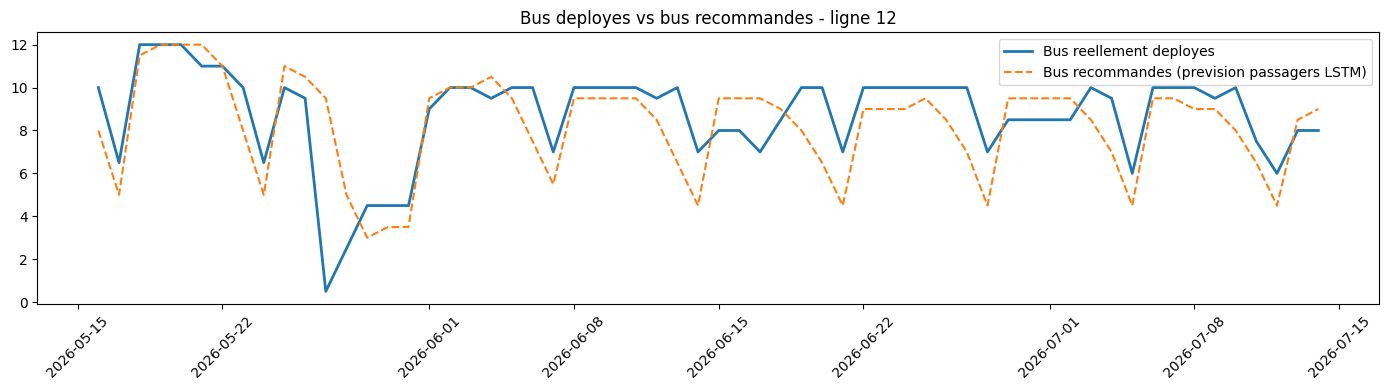

Ecart moyen (recommande - deploye) : -0.47 bus. Positif = sous-effectif actuel probable, negatif = sur-effectif probable.


In [28]:
plt.figure(figsize=(14,4))
plt.plot(comparaison_bus.index, comparaison_bus['bus_reellement_deployes'], label='Bus reellement deployes', linewidth=2)
plt.plot(comparaison_bus.index, comparaison_bus['bus_recommandes_selon_prediction'], label='Bus recommandes (prevision passagers LSTM)', linestyle='--')
plt.title(f'Bus deployes vs bus recommandes - ligne {LIGNE_REFERENCE}')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

ecart_moyen = (comparaison_bus['bus_recommandes_selon_prediction'] - comparaison_bus['bus_reellement_deployes']).mean()
print(f"Ecart moyen (recommande - deploye) : {ecart_moyen:.2f} bus. "
      f"Positif = sous-effectif actuel probable, negatif = sur-effectif probable.")

### 7.1 Deux methodes pour estimer le nombre de bus, et comparaison
**Methode 1 - indirecte (calcul)** : celle utilisee ci-dessus. On predit les passagers avec le LSTM, puis on applique la formule `passagers / (capacite x rotations)`.

**Methode 2 - directe (Deep Learning)** : on entraine un **second LSTM**, avec la meme architecture et les memes features, mais dont la cible est directement `bus` (et non plus `passagers`). Le reseau apprend alors lui-meme la relation entre le contexte (jour, vacances, historique...) et le nombre de bus deployes, sans passer par une formule explicite.

On compare ensuite les deux sur les memes vrais chiffres de bus (`test_df['bus']`).

In [29]:
# Methode 2 : LSTM entraine directement sur la cible 'bus'
FEATURES_BUS = FEATURES + ['bus']
idx_bus = len(FEATURES)   # position de la colonne 'bus' (ajoutee en dernier)

scaler_bus = MinMaxScaler()
scaler_bus.fit(train_df[FEATURES_BUS])

train_bus_s = scaler_bus.transform(train_df[FEATURES_BUS])
val_bus_s   = scaler_bus.transform(val_df[FEATURES_BUS])
test_bus_s  = scaler_bus.transform(test_df[FEATURES_BUS])

X_train_bus, y_train_bus = create_sequences(train_bus_s, WINDOW_SIZE, target_col_idx=idx_bus)
X_val_bus,   y_val_bus   = create_sequences(val_bus_s,   WINDOW_SIZE, target_col_idx=idx_bus)
X_test_bus,  y_test_bus  = create_sequences(test_bus_s,  WINDOW_SIZE, target_col_idx=idx_bus)

model_bus = construire_modele(len(FEATURES_BUS), WINDOW_SIZE, MEILLEURS_HP)
model_bus.fit(
    X_train_bus, y_train_bus, validation_data=(X_val_bus, y_val_bus),
    epochs=150, batch_size=MEILLEUR_BATCH_SIZE, verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
)

y_pred_bus_scaled = model_bus.predict(X_test_bus).flatten()
y_pred_bus_direct = inverse_target(y_pred_bus_scaled, scaler_bus, len(FEATURES_BUS), target_idx=idx_bus)
y_true_bus = inverse_target(y_test_bus, scaler_bus, len(FEATURES_BUS), target_idx=idx_bus)

# on applique le meme arrondi realiste (multiples de 0.5, minimum 1 des qu'il y a de l'activite)
y_pred_bus_direct_arrondi = np.array([
    max(arrondir_au_demi(v), 1.0) if v > 0 else 0.0 for v in y_pred_bus_direct
])

model_bus.save(f'{MODELS_DIR}/lstm_bus_direct_ligne{LIGNE_REFERENCE}.keras')
joblib.dump(scaler_bus, f'{MODELS_DIR}/scaler_bus_ligne{LIGNE_REFERENCE}.pkl')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 475ms/step


['/content/drive/MyDrive/alsa_pfa_corrige/models/scaler_bus_ligne12.pkl']

In [30]:
resultats_bus = pd.DataFrame([
    evaluate(bus_effectivement_deployes, np.array(bus_recommandes_lstm), 'Methode 1 - calcul depuis passagers'),
    evaluate(bus_effectivement_deployes, y_pred_bus_direct_arrondi, 'Methode 2 - LSTM direct sur bus'),
])
resultats_bus

,Modele,MAE,RMSE,MAPE (%),R2
0,Methode 1 - calcul depuis passagers,1.383333,1.901754,46.128548,0.250906
1,Methode 2 - LSTM direct sur bus,1.175000,1.851801,44.828991,0.289742


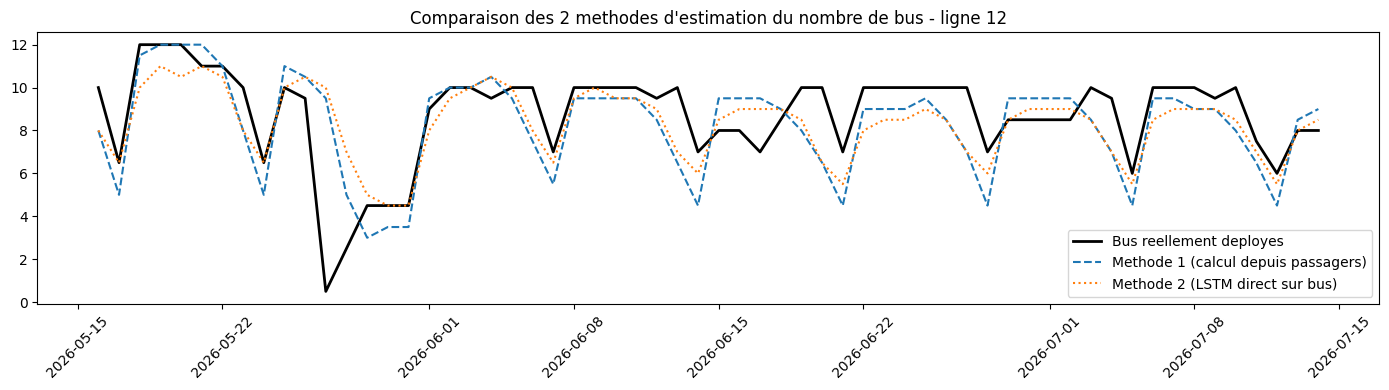

Methode la plus precise sur cette ligne : Methode 2 - LSTM direct sur bus


In [31]:
plt.figure(figsize=(14,4))
plt.plot(dates_test, bus_effectivement_deployes, label='Bus reellement deployes', linewidth=2, color='black')
plt.plot(dates_test, bus_recommandes_lstm, label='Methode 1 (calcul depuis passagers)', linestyle='--')
plt.plot(dates_test, y_pred_bus_direct_arrondi, label='Methode 2 (LSTM direct sur bus)', linestyle=':')
plt.title(f'Comparaison des 2 methodes d\'estimation du nombre de bus - ligne {LIGNE_REFERENCE}')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

meilleure_methode = resultats_bus.loc[resultats_bus['RMSE'].idxmin(), 'Modele']
print(f'Methode la plus precise sur cette ligne : {meilleure_methode}')

### 7.2 Affiner les rotations avec la duree reelle des trajets
ALSA a fourni la duree d'un **trajet aller simple** par ligne (en minutes). On peut s'en servir pour calculer un nombre de rotations **theorique** (physique), a comparer avec le nombre **empirique** (calibre sur `passagers`/`bus`, section 7) :

```
heures_de_service_par_bus = mediane(horas / bus)   # horas = heures cumulees de circulation
rotations_theoriques = heures_de_service_par_bus / (2 x duree_aller_simple_en_heures)
```

(le x2 vient du fait qu'une rotation = un aller + un retour). Teste sur toutes les lignes ou la duree est connue : cette hypothese (duree = trajet aller simple) colle nettement mieux a la calibration empirique que l'hypothese inverse (duree deja aller-retour) - erreur moyenne de ~4 rotations contre ~13. On la retient donc.

In [32]:
# Duree d'un trajet ALLER SIMPLE, en minutes, fournie par ALSA
DUREE_TRAJET_MIN = {
    '1': 25, '2': 40, '3': 50, '5': 60, '6': 40, '8': 46, '9': 30, '10': 30, '11': 45,
    '12': 65, '13': 30, '14': 30, '15': 50, '16': 60, '20': 45, '21': 40, '22': 60,
    '23': 40, '24': 10, '26': 65, '31': 60, '32': 60, '33': 90, '35': 40, '36': 70,
    '37': 60, '38': 60, '39': 30, '40': 70, '41': 80, '42': 100, '43': 60, '95': 50,
    '97': 45, '98': 40, '73': 45, '27': 30, 'AE': 45, '99': 30,
}

def calibrer_rotations_theorique(historique_df, duree_aller_min):
    """Calcule les rotations/jour a partir des heures de service reelles par bus
    (colonne 'horas' = heures cumulees de circulation ce jour-la) et de la duree du trajet.
    Renvoie None si le calcul n'est pas fiable (ligne trop peu active, donnees horas/bus
    quasi inexistantes -> ex. ligne 99, ou 'bus'>0 seulement quelques jours dans l'annee)."""
    h = historique_df[historique_df['bus'] > 0]
    if len(h) < 10 or duree_aller_min is None:
        return None
    heures_par_bus = (h['horas'] / h['bus']).median()
    if not np.isfinite(heures_par_bus) or heures_par_bus <= 0:
        return None
    duree_aller_retour_h = (2 * duree_aller_min) / 60
    rotations = heures_par_bus / duree_aller_retour_h
    if not np.isfinite(rotations) or rotations <= 0:
        return None
    return rotations

def rotations_finales(ligne, historique_df, type_ligne):
    """Utilise la methode theorique (duree de trajet) quand elle est disponible pour la ligne,
    sinon se rabat sur la calibration empirique (passagers/bus)."""
    duree = DUREE_TRAJET_MIN.get(str(ligne))
    rot_theo = calibrer_rotations_theorique(historique_df, duree)
    if rot_theo is not None:
        return rot_theo
    return calibrer_rotations_par_jour(historique_df, type_ligne)

In [33]:
# Comparaison theorique vs empirique, sur toutes les lignes ou la duree est connue
comparaison_rotations = []
for ligne_c, duree_c in DUREE_TRAJET_MIN.items():
    if ligne_c not in df['ligne'].unique():
        continue
    hist_c = preparer_serie(df, ligne_c)
    type_c = hist_c['type_ligne'].mode()[0]
    rot_emp_c = calibrer_rotations_par_jour(hist_c, type_c)
    rot_theo_c = calibrer_rotations_theorique(hist_c, duree_c)
    comparaison_rotations.append({
        'ligne': ligne_c, 'type_ligne': type_c, 'duree_aller_min': duree_c,
        'rotations_empirique': round(rot_emp_c, 1),
        'rotations_theorique': round(rot_theo_c, 1) if rot_theo_c else None,
        'ecart': round(abs(rot_theo_c - rot_emp_c), 1) if rot_theo_c else None,
    })

comparaison_rotations_df = pd.DataFrame(comparaison_rotations).sort_values('ecart')
print('Ecart moyen theorique vs empirique :', comparaison_rotations_df['ecart'].mean().round(1))
comparaison_rotations_df

Ecart moyen theorique vs empirique : 4.3


,ligne,type_ligne,duree_aller_min,rotations_empirique,rotations_theorique,ecart
22,35,REG,40,10.3,10.4,0.0
32,97,URB,45,9.2,9.3,0.1
19,31,REG,60,7.4,7.3,0.2
8,11,URB,45,9.0,9.4,0.4
33,98,URB,40,9.8,10.3,0.5
2,3,URB,50,9.0,8.4,0.6
30,43,REG,60,6.5,7.1,0.7
5,8,URB,46,8.8,9.7,0.9
27,40,REG,70,7.2,6.2,0.9
25,38,REG,60,8.2,7.2,1.1


In [34]:
# On recalcule la rotation de la ligne de reference avec la methode affinee, pour la suite du notebook
rotations_reference = rotations_finales(LIGNE_REFERENCE, train_df, type_ligne_reference)
print(f'Ligne {LIGNE_REFERENCE} : rotations affinees = {rotations_reference:.1f}/jour '
      f'(contre {calibrer_rotations_par_jour(train_df, type_ligne_reference):.1f} avec la seule methode empirique)')

Ligne 12 : rotations affinees = 6.8/jour (contre 9.4 avec la seule methode empirique)


**Lecture du tableau** : un grand ecart entre les deux methodes ne signifie pas forcement que la duree de trajet est fausse - ca peut aussi reveler des donnees `bus` peu fiables pour cette ligne (saisie irreguliere), auquel cas la methode theorique (basee sur la duree, independante de l'historique de saisie) est probablement **plus fiable**. A partir de maintenant, `rotations_finales()` remplace `calibrer_rotations_par_jour()` partout dans le notebook : elle utilise la duree quand elle est connue pour la ligne, sinon se rabat sur la methode empirique.

NE LEXECUTE PAS

### 7.3 Prevision sur un intervalle de dates choisi
Au-dela de la periode de test, on peut demander une prevision pour n'importe quelle date future (ou un intervalle de dates), exactement comme le fera l'API. Utile pour explorer les resultats directement dans Colab, sans passer par FastAPI.

In [35]:
def previsions_intervalle(ligne, modele, scaler, date_debut, date_fin, rotations):
    """Prevoit jour par jour, du dernier jour connu jusqu'a date_fin, puis ne renvoie que
    les jours compris entre date_debut et date_fin (intervalle demande par l'utilisateur)."""
    historique = preparer_serie(df, ligne)
    type_l = historique['type_ligne'].mode()[0]
    derniere_date = historique.index[-1]
    horizon = (pd.Timestamp(date_fin) - derniere_date).days
    if horizon < 1:
        raise ValueError(f"date_fin doit etre posterieure a {derniere_date.date()}")

    chemin = []
    for _ in range(horizon):
        feat = add_features(historique)
        derniere_fenetre = feat[FEATURES].iloc[-WINDOW_SIZE:].values
        X = scaler.transform(derniere_fenetre)[np.newaxis, :, :]
        y_scaled = modele.predict(X, verbose=0).flatten()[0]
        p = inverse_target(np.array([y_scaled]), scaler, len(FEATURES))[0]

        prochaine_date = historique.index[-1] + pd.Timedelta(days=1)
        if str(ligne) == '73' and prochaine_date.month in (7, 8):
            p = 0.0
        bus_r = bus_necessaires(p, prochaine_date, type_l, rotations)
        chemin.append({'date': prochaine_date, 'passagers_predits': round(p, 1), 'bus_recommandes': bus_r})
        historique.loc[prochaine_date] = {'passagers': p, 'type_jour': 'LV', 'type_ligne': type_l, 'bus': np.nan}

    resultat = pd.DataFrame(chemin).set_index('date')
    return resultat.loc[date_debut:date_fin]

# Exemple : prevision sur un intervalle de 2 semaines, a adapter
DATE_DEBUT_EXEMPLE = (df['date'].max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
DATE_FIN_EXEMPLE = (df['date'].max() + pd.Timedelta(days=14)).strftime('%Y-%m-%d')

previsions_periode = previsions_intervalle(
    LIGNE_REFERENCE, model, scaler, DATE_DEBUT_EXEMPLE, DATE_FIN_EXEMPLE, rotations_reference
)
previsions_periode

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

,passagers_predits,bus_recommandes
date,,
2026-07-15,7351.2,12.0
2026-07-16,7240.7,12.0
2026-07-17,6585.3,11.0
2026-07-18,5174.8,8.5
2026-07-19,3710.9,6.0
2026-07-20,6929.6,11.5
2026-07-21,6972.8,11.5
2026-07-22,6959.5,11.5
2026-07-23,6879.6,11.5


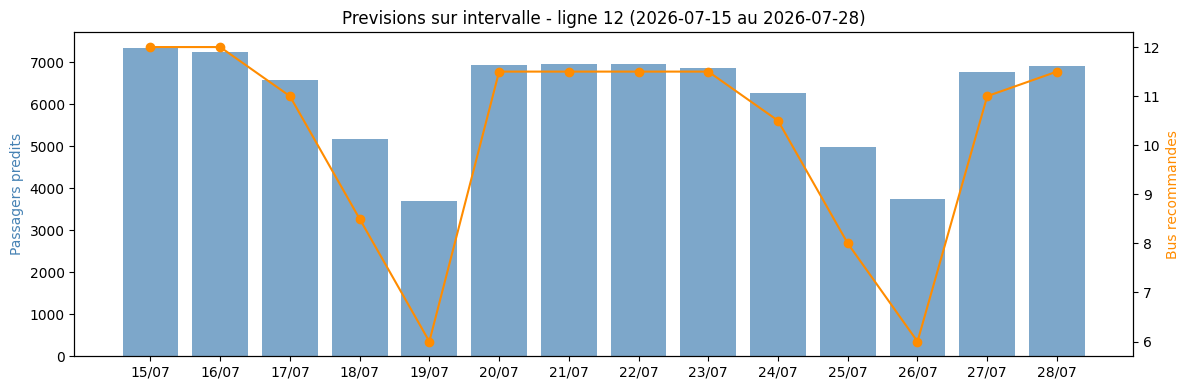

In [36]:
fig, ax1 = plt.subplots(figsize=(12,4))
ax1.bar(previsions_periode.index.strftime('%d/%m'), previsions_periode['passagers_predits'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Passagers predits', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(previsions_periode.index.strftime('%d/%m'), previsions_periode['bus_recommandes'], color='darkorange', marker='o')
ax2.set_ylabel('Bus recommandes', color='darkorange')
plt.title(f'Previsions sur intervalle - ligne {LIGNE_REFERENCE} ({DATE_DEBUT_EXEMPLE} au {DATE_FIN_EXEMPLE})')
plt.tight_layout(); plt.show()

## 8. Application du LSTM a TOUTES les lignes actives
On applique directement le LSTM (avec les hyperparametres trouves par Optuna sur la ligne de reference) a chacune des lignes actives. La comparaison avec les autres modeles (Random Forest, Holt-Winters) reste reservee a la ligne de reference (section 6) ; ici, l'objectif est d'obtenir un modele de prevision et une estimation de bus pour chaque ligne.

Le nombre d'epochs est reduit pour que la boucle reste raisonnable sur toutes les lignes ; vous pourrez reentrainer plus longuement une ligne precise en reprenant les sections 3 a 5 avec `LIGNE_REFERENCE` = la ligne choisie.

In [38]:
# preparer_serie est deja definie section 1 ; reutilisee ici pour toutes les lignes
def preparer_sequences(data_feat, window_size, features):
    n = len(data_feat)
    train_end = int(n*0.80)
    val_end   = int(n*0.90)
    train_df = data_feat.iloc[:train_end]
    val_df   = data_feat.iloc[train_end:val_end]
    test_df  = data_feat.iloc[val_end:]

    scaler = MinMaxScaler()
    scaler.fit(train_df[features])

    train_s = scaler.transform(train_df[features])
    val_s   = scaler.transform(val_df[features])
    test_s  = scaler.transform(test_df[features])

    X_train, y_train = create_sequences(train_s, window_size)
    X_val,   y_val   = create_sequences(val_s, window_size)
    X_test,  y_test  = create_sequences(test_s, window_size)
    return (X_train, y_train, X_val, y_val, X_test, y_test,
            scaler, train_df, val_df, test_df)

def entrainer_lstm_ligne(X_train, y_train, X_val, y_val, n_features, window_size,
                          ligne, models_dir, hp, batch_size, epochs=60, patience=8):
    m = construire_modele(n_features, window_size, hp)
    safe_name = str(ligne).replace(' ', '_').replace('/', '_')
    cb = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ModelCheckpoint(f'{models_dir}/lstm_ligne_{safe_name}.keras', save_best_only=True)
    ]
    m.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=0)
    return m

In [39]:
# Boucle principale sur toutes les lignes actives : LSTM uniquement
MIN_JOURS = WINDOW_SIZE * 4   # une ligne trop peu active (ex. navette speciale) est ignoree
toutes_les_lignes = sorted(df['ligne'].unique())
resultats_globaux = []
echecs = []

for ligne in toutes_les_lignes:
    try:
        serie_l = preparer_serie(df, ligne)
        if len(serie_l) < MIN_JOURS:
            echecs.append((ligne, 'historique trop court'))
            continue

        feat_l = add_features(serie_l)
        if len(feat_l) < MIN_JOURS:
            echecs.append((ligne, 'trop peu de donnees apres feature engineering'))
            continue

        (X_tr, y_tr, X_va, y_va, X_te, y_te,
         scaler_l, train_df_l, val_df_l, test_df_l) = preparer_sequences(feat_l, WINDOW_SIZE, FEATURES)

        if len(X_te) == 0 or len(X_tr) == 0:
            echecs.append((ligne, 'sequences insuffisantes pour le split train/val/test'))
            continue

        model_l = entrainer_lstm_ligne(X_tr, y_tr, X_va, y_va, len(FEATURES), WINDOW_SIZE,
                                        ligne, MODELS_DIR, MEILLEURS_HP, MEILLEUR_BATCH_SIZE)
        joblib.dump(scaler_l, f'{MODELS_DIR}/scaler_ligne_{str(ligne).replace(" ","_").replace("/","_")}.pkl')

        y_pred_lstm_l = inverse_target(model_l.predict(X_te, verbose=0).flatten(), scaler_l, len(FEATURES))
        y_true_l = inverse_target(y_te, scaler_l, len(FEATURES))
        r_lstm = evaluate(y_true_l, y_pred_lstm_l, 'LSTM')

        # estimation du nombre de bus necessaires a partir de la prevision LSTM
        # (rotations calibrees sur le train de CETTE ligne, jamais sur le test)
        type_ligne_l = test_df_l['type_ligne'].mode()[0]
        rotations_l = rotations_finales(ligne, train_df_l, type_ligne_l)
        dates_test_l = test_df_l.index[WINDOW_SIZE:]
        bus_recommandes_l = [bus_necessaires(p, dt, type_ligne_l, rotations_l) for p, dt in zip(y_pred_lstm_l, dates_test_l)]
        bus_deployes_l = test_df_l['bus'].iloc[WINDOW_SIZE:].values
        ecart_bus_moyen_l = float(np.mean(np.array(bus_recommandes_l) - bus_deployes_l))

        resultats_globaux.append({
            'ligne': ligne,
            'type_ligne': type_ligne_l,
            'rotations_par_jour': round(rotations_l, 1),
            'nb_jours': len(feat_l),
            'MAE_lstm': r_lstm['MAE'], 'RMSE_lstm': r_lstm['RMSE'],
            'MAPE_lstm': r_lstm['MAPE (%)'], 'R2_lstm': r_lstm['R2'],
            'ecart_bus_moyen': ecart_bus_moyen_l
        })
        print(f'Ligne {ligne} : OK (RMSE = {r_lstm["RMSE"]:.1f})')

    except Exception as e:
        echecs.append((ligne, str(e)))
        print(f'Ligne {ligne} : ECHEC -> {e}')

print('\nTermine.', len(resultats_globaux), 'lignes traitees avec succes,', len(echecs), 'echecs.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne 1 : OK (RMSE = 165.7)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne 10 : OK (RMSE = 70.2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Ligne 98 : OK (RMSE = 1114.8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne 99 : OK (RMSE = 160.4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Ligne AE : OK (RMSE = 33.3)

Termine. 38 lignes traitees avec succes, 0 echecs.


In [40]:
synthese = pd.DataFrame(resultats_globaux).sort_values('RMSE_lstm')
print('Lignes en echec :', echecs)
synthese

Lignes en echec : []


,ligne,type_ligne,rotations_par_jour,nb_jours,MAE_lstm,RMSE_lstm,MAPE_lstm,R2_lstm,ecart_bus_moyen
37,AE,REG,8.3,896,26.085843,33.256150,42.838233,-0.079120,-2.000000
32,9,URB,1.0,896,15.719883,41.620966,739.839685,0.027483,0.716667
6,15,URB,9.2,896,52.426486,69.992792,1932.815041,0.523993,0.233333
1,10,URB,24.9,896,52.881642,70.230480,1955.548553,0.227582,0.233333
5,14,URB,14.7,896,58.587492,91.183474,792.031969,0.052400,0.016667
21,37,REG,7.3,896,92.588888,108.260504,1445.675127,0.374785,0.183333
23,39,REG,15.1,896,92.873920,120.041062,2437.800846,0.573137,0.200000
4,13,URB,15.2,896,97.740012,143.415612,985.160605,0.103459,0.058333
36,99,URB,1.0,896,158.797584,160.377121,15879.758413,0.000000,1.833333
0,1,URB,12.1,896,127.037735,165.738797,3487.308576,0.285230,-0.675000


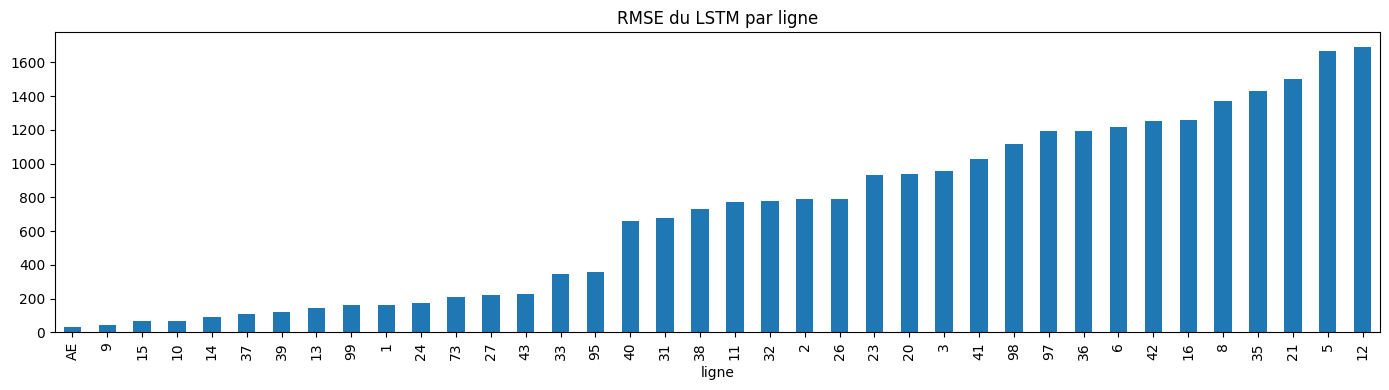

In [41]:
# Sauvegarde du tableau de synthese pour le rapport
REPORTS_DIR = '/content/drive/MyDrive/PFA_ALSA_Prevision_Demande/reports'
os.makedirs(REPORTS_DIR, exist_ok=True)
synthese.to_csv(f'{REPORTS_DIR}/synthese_metriques_par_ligne.csv', index=False)

# Distribution du RMSE selon les lignes, pour reperer visuellement les lignes bien/mal predites
synthese.set_index('ligne')['RMSE_lstm'].sort_values().plot(
    kind='bar', figsize=(14,4), title='RMSE du LSTM par ligne')
plt.tight_layout(); plt.show()

## 9. Modele global : un seul LSTM entraine sur TOUTES les lignes
Contrairement a la section 8 (un modele different par ligne), on entraine ici **un seul reseau** qui voit les sequences de toutes les lignes a la fois. Chaque ligne garde sa propre normalisation (un `MinMaxScaler` par ligne, sinon une grande ligne ecraserait les petites), mais on ajoute a chaque sequence un encodage one-hot de la ligne (comme une carte d'identite) pour que le reseau sache 'de quelle ligne' il regarde l'historique.

**Interet** : un seul modele a maintenir/redeployer, et les lignes avec peu d'historique beneficient de ce que le modele a appris sur les lignes plus fournies (transfert d'apprentissage implicite). **Limite** : moins specialise par ligne qu'un modele dedie -> a comparer avec la section 8.

In [42]:
lignes_modele_global = sorted(df['ligne'].unique())
n_lignes = len(lignes_modele_global)
ligne_vers_index = {l: i for i, l in enumerate(lignes_modele_global)}

X_train_all, y_train_all = [], []
X_val_all, y_val_all = [], []
X_test_all, y_test_all = [], []
scalers_par_ligne = {}
segments_test = []   # (ligne, nb_points_test) dans l'ordre de concatenation, pour re-separer plus tard

def ajouter_onehot(X, onehot):
    # repete le vecteur one-hot de la ligne sur chaque pas de temps de la sequence
    oh = np.tile(onehot, (X.shape[0], X.shape[1], 1))
    return np.concatenate([X, oh], axis=2)

for ligne in lignes_modele_global:
    try:
        serie_l = preparer_serie(df, ligne)
        if len(serie_l) < MIN_JOURS:
            continue
        feat_l = add_features(serie_l)
        if len(feat_l) < MIN_JOURS:
            continue

        (X_tr, y_tr, X_va, y_va, X_te, y_te,
         scaler_l, train_df_l, val_df_l, test_df_l) = preparer_sequences(feat_l, WINDOW_SIZE, FEATURES)
        if len(X_tr) == 0 or len(X_te) == 0:
            continue

        onehot = np.zeros(n_lignes)
        onehot[ligne_vers_index[ligne]] = 1

        X_train_all.append(ajouter_onehot(X_tr, onehot)); y_train_all.append(y_tr)
        X_val_all.append(ajouter_onehot(X_va, onehot));   y_val_all.append(y_va)
        X_test_all.append(ajouter_onehot(X_te, onehot));  y_test_all.append(y_te)

        scalers_par_ligne[ligne] = scaler_l
        segments_test.append((ligne, len(X_te)))
    except Exception as e:
        print(f'Ligne {ligne} ignoree pour le modele global : {e}')

X_train_all = np.concatenate(X_train_all, axis=0)
y_train_all = np.concatenate(y_train_all, axis=0)
X_val_all   = np.concatenate(X_val_all, axis=0)
y_val_all   = np.concatenate(y_val_all, axis=0)
X_test_all  = np.concatenate(X_test_all, axis=0)
y_test_all  = np.concatenate(y_test_all, axis=0)

print('Shape modele global - train/val/test :', X_train_all.shape, X_val_all.shape, X_test_all.shape)

Shape modele global - train/val/test : (25958, 30, 58) (2266, 30, 58) (2266, 30, 58)


In [43]:
# NB : le modele global voit beaucoup plus de donnees (toutes les lignes concatenees),
# on lui donne donc plus de capacite que les hyperparametres trouves par Optuna sur une
# seule ligne de reference (128/64 au lieu de MEILLEURS_HP) ; a ajuster si vous voulez retenter
# une recherche Optuna dediee au modele global.
model_global = Sequential([
    LSTM(128, return_sequences=True, input_shape=(WINDOW_SIZE, X_train_all.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_global.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_global.summary()

history_global = model_global.fit(
    X_train_all, y_train_all, validation_data=(X_val_all, y_val_all),
    epochs=100, batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint(f'{MODELS_DIR}/lstm_global_toutes_lignes.keras', save_best_only=True)
    ],
    verbose=1
)

import pickle
with open(f'{MODELS_DIR}/scalers_par_ligne.pkl', 'wb') as f:
    pickle.dump(scalers_par_ligne, f)
with open(f'{MODELS_DIR}/lignes_modele_global.pkl', 'wb') as f:
    pickle.dump(lignes_modele_global, f)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_120 (LSTM)                 │ (None, 30, 128)        │        95,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_121 (LSTM)                 │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_121 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,265 (575.25 KB)

 Trainable params: 147,265 (575.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 49s 109ms/step - loss: 0.0255 - mae: 0.1163 - val_loss: 0.0139 - val_mae: 0.0897
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - loss: 0.0165 - mae: 0.0917 - val_loss: 0.0103 - val_mae: 0.0756
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - loss: 0.0127 - mae: 0.0788 - val_loss: 0.0100 - val_mae: 0.0747
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - loss: 0.0114 - mae: 0.0736 - val_loss: 0.0091 - val_mae: 0.0711
Epoch 5/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - loss: 0.0105 - mae: 0.0700 - val_loss: 0.0096 - val_mae: 0.0725
Epoch 6/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - loss: 0.0099 - mae: 0.0673 - val_loss: 0.0087 - val_mae: 0.0695
Epoch 7/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - loss: 0.0093 - mae: 0.0648 - val_loss: 0.0088 - val_mae: 0.0695
Epoch 8/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - loss: 0.0090 - mae: 0.0632 - val_loss: 0.0090 - val_mae: 0.0699
Epoch 9/100
406/406 ━━━━

In [44]:
# Evaluation ligne par ligne (chaque ligne garde son propre scaler pour revenir a l'echelle reelle)
y_pred_scaled_all = model_global.predict(X_test_all, verbose=0).flatten()

resultats_modele_global = []
pointeur = 0
for ligne, n_pts in segments_test:
    y_true_scaled = y_test_all[pointeur:pointeur+n_pts]
    y_pred_scaled = y_pred_scaled_all[pointeur:pointeur+n_pts]
    scaler_l = scalers_par_ligne[ligne]
    y_true_l = inverse_target(y_true_scaled, scaler_l, len(FEATURES))
    y_pred_l = inverse_target(y_pred_scaled, scaler_l, len(FEATURES))
    resultats_modele_global.append(evaluate(y_true_l, y_pred_l, ligne))
    pointeur += n_pts

resultats_modele_global_df = pd.DataFrame(resultats_modele_global).rename(columns={'Modele': 'ligne'})
resultats_modele_global_df.sort_values('RMSE')

,ligne,MAE,RMSE,MAPE (%),R2
37,AE,23.419094,28.322882,34.001391,0.217291
32,9,26.962617,43.505659,1961.322053,-0.062586
6,15,44.369861,63.636976,1136.664468,0.606517
1,10,46.649961,65.067802,1770.743991,0.336970
36,99,60.152802,71.363054,6015.280169,0.000000
21,37,59.425420,80.000649,994.829590,0.658590
12,24,62.779219,85.721107,51.540436,0.563608
5,14,64.845803,89.924504,607.993784,0.078386
23,39,69.111656,96.580321,1844.934115,0.723684
4,13,87.761537,119.095345,552.389205,0.381746


In [45]:
# Comparaison rapide : modele global (un seul LSTM) vs modeles par ligne (section 8)
comparaison_approches = pd.merge(
    resultats_modele_global_df[['ligne', 'RMSE']].rename(columns={'RMSE': 'RMSE_modele_global'}),
    synthese[['ligne', 'RMSE_lstm']].rename(columns={'RMSE_lstm': 'RMSE_modele_par_ligne'}),
    on='ligne'
)
comparaison_approches['meilleure_approche'] = np.where(
    comparaison_approches['RMSE_modele_global'] < comparaison_approches['RMSE_modele_par_ligne'],
    'Modele global', 'Modele par ligne'
)
print(comparaison_approches['meilleure_approche'].value_counts())
comparaison_approches.sort_values('RMSE_modele_global')

meilleure_approche
Modele global       36
Modele par ligne     2
Name: count, dtype: int64


,ligne,RMSE_modele_global,RMSE_modele_par_ligne,meilleure_approche
37,AE,28.322882,33.256150,Modele global
32,9,43.505659,41.620966,Modele par ligne
6,15,63.636976,69.992792,Modele global
1,10,65.067802,70.230480,Modele global
36,99,71.363054,160.377121,Modele global
21,37,80.000649,108.260504,Modele global
12,24,85.721107,175.197742,Modele global
5,14,89.924504,91.183474,Modele global
23,39,96.580321,120.041062,Modele global
4,13,119.095345,143.415612,Modele global


## 10. Interpretation et recommandations
A completer une fois les resultats obtenus, pour votre rapport final :
- Quelles lignes ont le RMSE le plus faible/eleve (section 8) ? Est-ce lie a la quantite de donnees disponibles, a la regularite de la ligne, ou a des evenements particuliers (cf. la comparaison LSTM vs Random Forest/Holt-Winters sur la ligne de reference, section 6, pour discuter si le LSTM est le bon choix par rapport aux alternatives) ?
- Modele global (section 9) vs un modele par ligne (section 8) : lequel generalise le mieux, et sur quel type de lignes (grandes lignes bien fournies en donnees vs petites lignes recentes) ?
- Quels jours de semaine et quelles periodes (vacances scolaires `OTROS`, jours feries, Aid El Fitr/Aid El Adha) concentrent la plus forte et la plus faible affluence, par ligne ou par type de ligne (URB/REG) ?
- D'apres la section 8, ALSA deploie-t-elle en moyenne trop ou pas assez de bus par rapport a la demande prevue, et sur quelles lignes l'ecart est-il le plus marque ?
- Recommandations operationnelles concretes : lignes/periodes ou renforcer ou reduire le nombre de bus, vigilance particuliere sur les periodes de vacances scolaires.
- Limites du travail : qualite/disponibilite des donnees, hypotheses de capacite, pistes d'amelioration (donnees meteo, evenements locaux, plus d'historique).

## 11. (Optionnel) Demo rapide de l'API depuis Colab avec pyngrok
Pour une VRAIE utilisation avec le binome, lancez FastAPI sur un poste qui reste allume (voir `api_prevision_alsa.py`, a executer sur votre desktop). Cette section sert uniquement a tester/demontrer rapidement depuis Colab, en exposant temporairement le serveur via une URL publique ngrok. Cette URL expire des que la session Colab se ferme -> jamais pour la version finale.

In [ ]:
!pip install -q fastapi uvicorn pyngrok nest_asyncio

from pyngrok import ngrok
import nest_asyncio, uvicorn, threading

# Cle ngrok gratuite a creer sur https://dashboard.ngrok.com/get-started/your-authtoken
# ngrok.set_auth_token('VOTRE_TOKEN_NGROK')

nest_asyncio.apply()
public_url = ngrok.connect(8000)
print('API accessible publiquement (temporairement) sur :', public_url)
print('Documentation interactive :', str(public_url) + '/docs')

# NB : necessite que api_prevision_alsa.py (+ dossiers models/, data/, reports/)
# soient presents dans le repertoire courant de Colab (copiez-les depuis Drive).
# from api_prevision_alsa import app
# threading.Thread(target=lambda: uvicorn.run(app, host='0.0.0.0', port=8000)).start()